In [78]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine,inspect
from dotenv import load_dotenv



In [79]:
# Wczytaj dane z pliku .env
load_dotenv()

DB_USER = os.getenv('DB_USER')
DB_PASS = os.getenv('DB_PASS')
DB_HOST = os.getenv('DB_HOST')
DB_PORT = os.getenv('DB_PORT')
DB_NAME = os.getenv('DB_NAME')

In [80]:
## Ustawienie estetyczne wykresów
sns.set_theme(style="whitegrid")



In [81]:
engine = create_engine(f'postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}')



In [82]:
# Import danych z plików CSV do bazy PostgreSQL
def import_data_to_postgres():
    files = {
        'products.csv': 'products',
        'orders.csv': 'orders',
        'order_items.csv': 'order_items',
        'users.csv': 'users'
    }
    
    inspector = inspect(engine)
    existing_tables = inspector.get_table_names()

    for file_name, table_name in files.items():
        try:
            
            if table_name in existing_tables:
                print(f"Pominięto: Tabela '{table_name}' już istnieje w bazie.")
                continue

            print(f"Wczytywanie {file_name}...")
            df = pd.read_csv(file_name)
            
            df.to_sql(table_name, engine, if_exists='fail', index=False) 
            print(f"Sukces: Tabela '{table_name}' została załadowana ({len(df)} wierszy).")

        except Exception as e:
            print(f"Błąd przy pliku {file_name}: {e}")

import_data_to_postgres()

Pominięto: Tabela 'products' już istnieje w bazie.
Pominięto: Tabela 'orders' już istnieje w bazie.
Pominięto: Tabela 'order_items' już istnieje w bazie.
Pominięto: Tabela 'users' już istnieje w bazie.


<h2 style="color:#95d5b2">Jaka jest średnia wartość zamówienia dla klientów w wieku 30-40 lat, z podziałem na państwa? </h2>

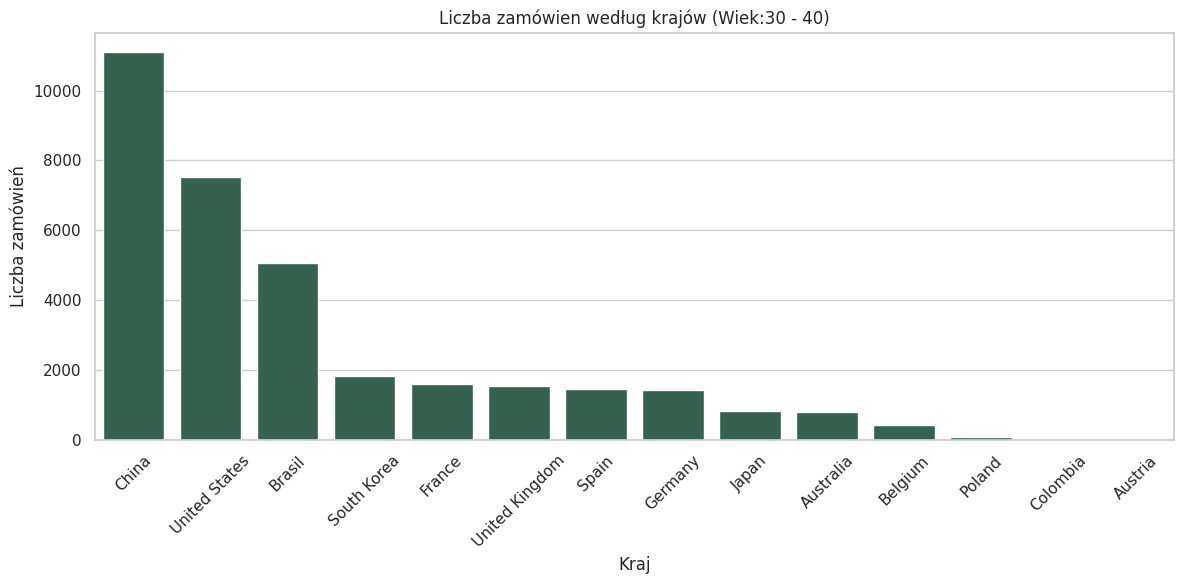

In [83]:
def analyze_orders_by_country(engine,min_age,max_age):

    query = f"""
    SELECT 
        u.country AS kraj,
        COUNT(*) AS ilosc_zamowien
    FROM users AS u 
    JOIN order_items AS oi ON u.id = oi.user_id
    WHERE u.age BETWEEN {min_age} AND {max_age}
    GROUP BY u.country
    ORDER BY ilosc_zamowien DESC
    """

    df = pd.read_sql(query,engine)

    plt.figure(figsize=(12,6))
    sns.barplot(x='kraj', y='ilosc_zamowien', data=df, color='#2d6a4f')

    plt.title(f'Liczba zamówien według krajów (Wiek:{min_age} - {max_age})')
    plt.xlabel('Kraj')
    plt.ylabel('Liczba zamówień')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

analyze_orders_by_country(engine,30,40)


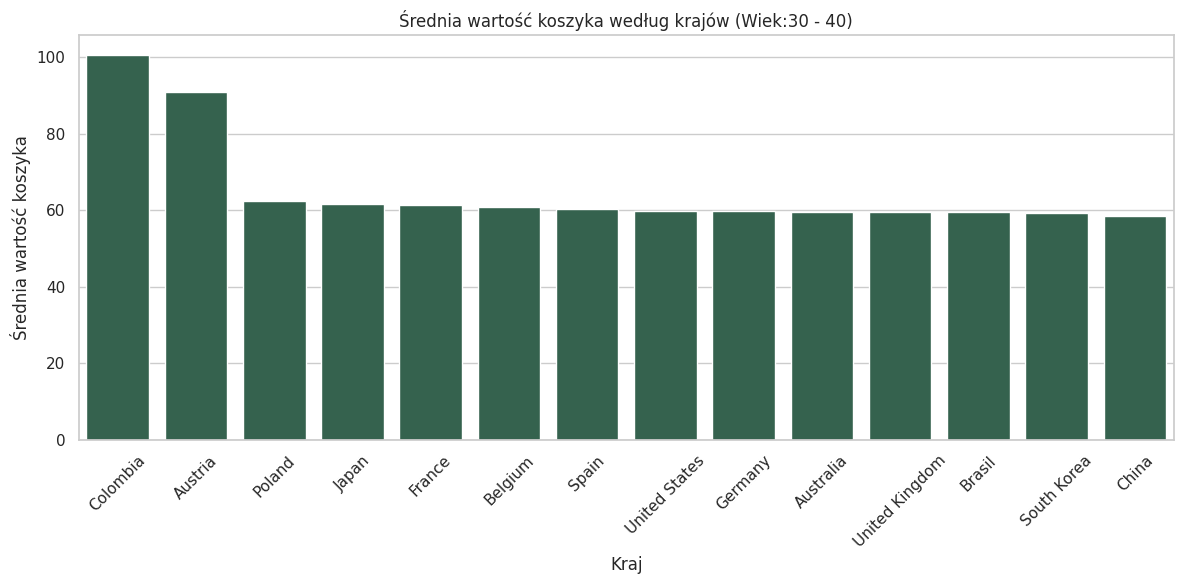

In [87]:
def analyze_average_order_value(engine,min_age,max_age):

    query =f"""
    SELECT 
        u.country AS kraj,
        ROUND(AVG(oi.sale_price)::numeric,2) AS srednia_wartosc_koszyka
    FROM users AS u 
    JOIN order_items AS oi ON u.id = oi.user_id
    WHERE u.age BETWEEN {min_age} AND {max_age}
    GROUP BY u.country
    ORDER BY srednia_wartosc_koszyka DESC
    """

    df = pd.read_sql(query, engine)

    plt.figure(figsize=(12,6))
    sns.barplot(x='kraj', y='srednia_wartosc_koszyka', data=df, color='#2d6a4f')

    plt.title(f'Średnia wartość koszyka według krajów (Wiek:{min_age} - {max_age})')
    plt.xlabel('Kraj')
    plt.ylabel('Średnia wartość koszyka')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

analyze_average_order_value(engine,30,40)